In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import datetime
from scipy import stats
import uproot
from scipy.stats import linregress


### 🌡️ TABLA COMPARATIVA: SENSIBILIDADES TÉRMICAS (3 EXPERIMENTOS)
> *Nota: Ver detalles al final del notebook 11-02-26*

| Sensor | 02/02 | 04/02 | 11/02 | Δ(02↔04) | Δ(04↔11) | Δ(02↔11) |
| :--- | :--- | :--- | :--- | :--- | :--- | :--- |
| **FBG-1** | 4.65 pm/K | 4.60 pm/K | 4.78 pm/K | -1.08% | +3.96% | +2.84% |
| **FBG-2** | 4.66 pm/K | 4.63 pm/K | 4.68 pm/K | -0.64% | +1.10% | +0.45% |
| **FBG-3** | 4.79 pm/K | 4.72 pm/K | 4.80 pm/K | -1.46% | +1.73% | +0.24% |
| **FBG-4** | *N/A* | 4.72 pm/K | 4.75 pm/K | *N/A* | +0.58% | *N/A* |

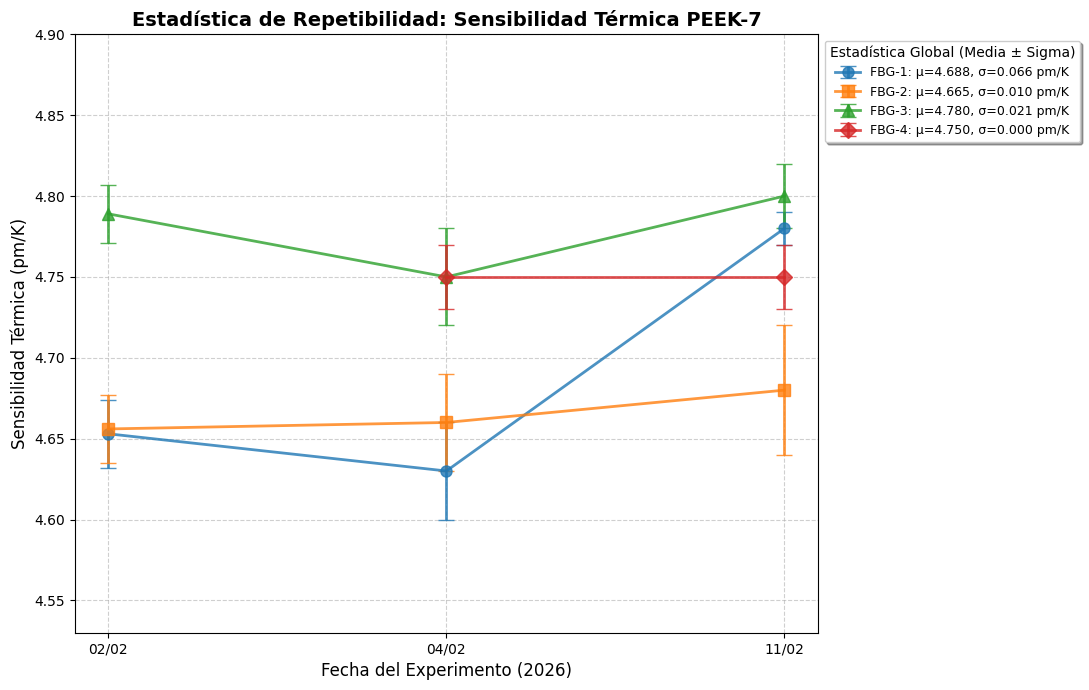

                                  🌡️  TABLA COMPARATIVA Y ESTADÍSTICA DE REPETIBILIDAD                                  
Sensor     02/02              04/02              11/02              Estadística (μ±σ)      Δ Máx (%) 
------------------------------------------------------------------------------------------------------------------------
FBG-1      4.653±0.021        4.630±0.030        4.780±0.010        4.688 ± 0.066            3.24%   
FBG-2      4.656±0.021        4.660±0.030        4.680±0.040        4.665 ± 0.010            0.52%   
FBG-3      4.789±0.018        4.750±0.030        4.800±0.020        4.780 ± 0.021            1.05%   
FBG-4      N/A                4.750±0.020        4.750±0.020        4.750 ± 0.000            0.00%   


In [14]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# 1. Datos de entrada (Sensibilidad ± Error en pm/K)
dates = ['02/02', '04/02', '11/02']
sensors_data = {
    'FBG-1': {'vals': [4.653, 4.630, 4.780], 'errs': [0.021, 0.030, 0.010]},
    'FBG-2': {'vals': [4.656, 4.660, 4.680], 'errs': [0.021, 0.030, 0.040]},
    'FBG-3': {'vals': [4.789, 4.750, 4.800], 'errs': [0.018, 0.030, 0.020]},
    'FBG-4': {'vals': [None, 4.750, 4.750], 'errs': [None, 0.020, 0.020]}
}

# 2. Creación del Gráfico de Repetibilidad con Estadística en Leyenda
plt.figure(figsize=(11, 7))
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
markers = ['o', 's', '^', 'D']

for i, (sensor, data) in enumerate(sensors_data.items()):
    # Filtrar valores N/A para el cálculo y el plot
    valid_vals = [v for v in data['vals'] if v is not None]
    valid_idx = [j for j, val in enumerate(data['vals']) if val is not None]
    
    # Calcular estadística global del sensor (Repetibilidad entre días)
    mean_rep = np.mean(valid_vals)
    sigma_rep = np.std(valid_vals) # Desviación estándar de los valores diarios
    
    plot_dates = [dates[j] for j in valid_idx]
    plot_vals = [data['vals'][j] for j in valid_idx]
    plot_errs = [data['errs'][j] for j in valid_idx]
    
    # Etiqueta de la leyenda con μ y σ
    label_stat = f'{sensor}: μ={mean_rep:.3f}, σ={sigma_rep:.3f} pm/K'
    
    plt.errorbar(plot_dates, plot_vals, yerr=plot_errs, 
                 fmt=markers[i], color=colors[i], label=label_stat,
                 capsize=6, markersize=8, linestyle='-', linewidth=2, alpha=0.8)

plt.title('Estadística de Repetibilidad: Sensibilidad Térmica PEEK-7', fontsize=14, fontweight='bold')
plt.xlabel('Fecha del Experimento (2026)', fontsize=12)
plt.ylabel('Sensibilidad Térmica (pm/K)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)

# Leyenda con cuadro informativo
plt.legend(title='Estadística Global (Media ± Sigma)', fontsize=9, loc='upper left', 
           bbox_to_anchor=(1, 1), frameon=True, shadow=True)

# Ajuste del eje Y
all_vals = [v for s in sensors_data.values() for v in s['vals'] if v is not None]
plt.ylim(min(all_vals) - 0.1, max(all_vals) + 0.1)

plt.tight_layout()
plt.show()

# 3. Tabla Comparativa con Deltas (%)
print("="*120)
print(f"{'🌡️  TABLA COMPARATIVA Y ESTADÍSTICA DE REPETIBILIDAD':^120}")
print("="*120)
header = f"{'Sensor':<10} {'02/02':<18} {'04/02':<18} {'11/02':<18} {'Estadística (μ±σ)':<22} {'Δ Máx (%)':<10}"
print(header)
print("-" * 120)

for sensor, data in sensors_data.items():
    vals = data['vals']
    errs = data['errs']
    
    # Formatear celdas diarias
    s_days = [f"{v:.3f}±{e:.3f}" if v is not None else "N/A" for v, e in zip(vals, errs)]
    
    # Estadística para la tabla
    valid_vals = [v for v in vals if v is not None]
    m = np.mean(valid_vals)
    s = np.std(valid_vals)
    stat_str = f"{m:.3f} ± {s:.3f}"
    
    # Delta Máximo (peor caso entre cualquiera de los días)
    if len(valid_vals) > 1:
        d_max = ((max(valid_vals) - min(valid_vals)) / min(valid_vals)) * 100
        d_str = f"{d_max:>6.2f}%"
    else:
        d_str = "N/A"

    print(f"{sensor:<10} {s_days[0]:<18} {s_days[1]:<18} {s_days[2]:<18} {stat_str:<22} {d_str:<10}")

print("="*120)

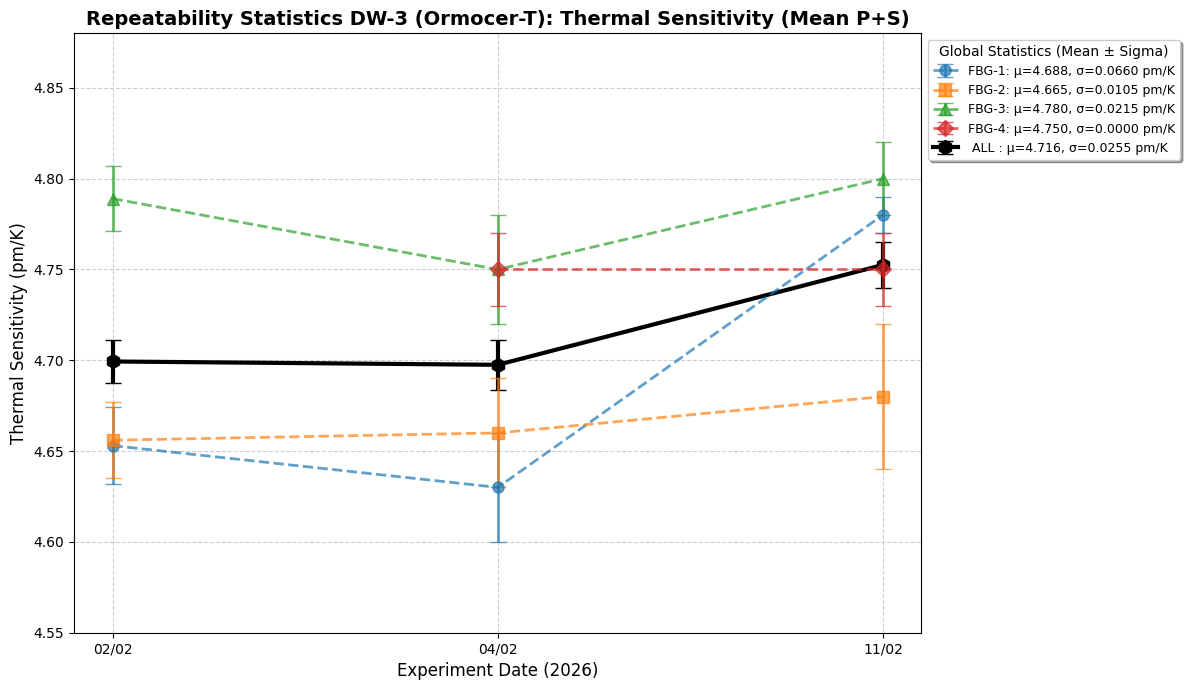

                        THERMAL SENSITIVITY COMPARATIVE TABLE AND REPEATABILITY STATISTICS (ALL FBGs)                        
Sensor     02/02              04/02              11/02              Mean (μ)     Sigma (σ)    Max Δ (%) 
-----------------------------------------------------------------------------------------------------------------------------
   FBG-1   4.653±0.021        4.630±0.030        4.780±0.010        4.688        0.0660         3.24%   
   FBG-2   4.656±0.021        4.660±0.030        4.680±0.040        4.665        0.0105         0.52%   
   FBG-3   4.789±0.018        4.750±0.030        4.800±0.020        4.780        0.0215         1.05%   
   FBG-4   N/A                4.750±0.020        4.750±0.020        4.750        0.0000         0.00%   
>> ALL     4.699±0.012        4.697±0.014        4.753±0.013        4.716        0.0255         1.17%   


In [16]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# 1. Input Data (Sensitivity ± Error in pm/K)
dates = ['02/02', '04/02', '11/02']
sensors_data = {
    'FBG-1': {'vals': [4.653, 4.630, 4.780], 'errs': [0.021, 0.030, 0.010]},
    'FBG-2': {'vals': [4.656, 4.660, 4.680], 'errs': [0.021, 0.030, 0.040]},
    'FBG-3': {'vals': [4.789, 4.750, 4.800], 'errs': [0.018, 0.030, 0.020]},
    'FBG-4': {'vals': [None, 4.750, 4.750], 'errs': [None, 0.020, 0.020]}
}

# --- GLOBAL MEAN CALCULATION (ALL) ---
all_vals_per_day = []
all_errs_per_day = []

for j in range(len(dates)):
    daily_vals = [s['vals'][j] for s in sensors_data.values() if s['vals'][j] is not None]
    daily_errs = [s['errs'][j] for s in sensors_data.values() if s['errs'][j] is not None]
    all_vals_per_day.append(np.mean(daily_vals))
    # Combined uncertainty of the network mean
    all_errs_per_day.append(np.sqrt(np.sum(np.square(daily_errs))) / len(daily_errs))

sensors_data['ALL'] = {'vals': all_vals_per_day, 'errs': all_errs_per_day}

# 2. Repeatability Plot Generation
plt.figure(figsize=(12, 7))
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', 'black']
markers = ['o', 's', '^', 'D', 'h']
linestyles = ['--', '--', '--', '--', '-']

for i, (sensor, data) in enumerate(sensors_data.items()):
    valid_idx = [j for j, val in enumerate(data['vals']) if val is not None]
    valid_vals = [data['vals'][j] for j in valid_idx]
    
    mean_rep = np.mean(valid_vals)
    sigma_rep = np.std(valid_vals) 
    
    plot_dates = [dates[j] for j in valid_idx]
    plot_vals = [data['vals'][j] for j in valid_idx]
    plot_errs = [data['errs'][j] for j in valid_idx]
    
    is_all = (sensor == 'ALL')
    label_stat = f'{sensor:^5}: μ={mean_rep:.3f}, σ={sigma_rep:.4f} pm/K'
    
    plt.errorbar(plot_dates, plot_vals, yerr=plot_errs, 
                 fmt=markers[i], color=colors[i], label=label_stat,
                 capsize=6, markersize=8 if not is_all else 10, 
                 linestyle=linestyles[i], linewidth=2 if not is_all else 3, 
                 alpha=0.7 if not is_all else 1.0, zorder=10 if is_all else 15)

plt.title('Repeatability Statistics DW-3 (Ormocer-T): Thermal Sensitivity (Mean P+S)', fontsize=14, fontweight='bold')
plt.xlabel('Experiment Date (2026)', fontsize=12)
plt.ylabel('Thermal Sensitivity (pm/K)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(title='Global Statistics (Mean ± Sigma)', fontsize=9, loc='upper left', 
           bbox_to_anchor=(1, 1), frameon=True, shadow=True)

all_flat_vals = [v for s in sensors_data.values() for v in s['vals'] if v is not None]
plt.ylim(min(all_flat_vals) - 0.08, max(all_flat_vals) + 0.08)

plt.tight_layout()
plt.show()

# 3. Final Comparative Table
print("="*125)
print(f"{'THERMAL SENSITIVITY COMPARATIVE TABLE AND REPEATABILITY STATISTICS (ALL FBGs)':^125}")
print("="*125)
header = f"{'Sensor':<10} {'02/02':<18} {'04/02':<18} {'11/02':<18} {'Mean (μ)':<12} {'Sigma (σ)':<12} {'Max Δ (%)':<10}"
print(header)
print("-" * 125)

for sensor, data in sensors_data.items():
    vals = data['vals']
    errs = data['errs']
    s_days = [f"{v:.3f}±{e:.3f}" if v is not None else "N/A" for v, e in zip(vals, errs)]
    valid_vals = [v for v in vals if v is not None]
    m = np.mean(valid_vals)
    s = np.std(valid_vals)
    
    if len(valid_vals) > 1:
        d_max = ((max(valid_vals) - min(valid_vals)) / min(valid_vals)) * 100
        d_str = f"{d_max:>6.2f}%"
    else:
        d_str = "N/A"

    prefix = ">> " if sensor == 'ALL' else "   "
    print(f"{prefix}{sensor:<7} {s_days[0]:<18} {s_days[1]:<18} {s_days[2]:<18} {m:<12.3f} {s:<12.4f} {d_str:<10}")

print("="*125)

# **Characterization Report: DW-3 Fiber (Ormocer-T)**

This report consolidates the thermal sensitivity measurements conducted during February and March 2025 for the **Ormocer-T** coated fiber (DW-3).

---

## **1. Early February Series (Low Sensitivity Results)**
Analysis of the initial DW-3 batch. These experiments show high linearity ($R^2 > 0.999$) and consistent behavior across the 4-sensor network.

### **Individual Sensor Results**
| Date | Sensor | Sensitivity (pm/K) | Error (± pm/K) | R² | Plateaus |
| :--- | :--- | :---: | :---: | :---: | :---: |
| **Feb 02** | FBG-1 | 4.653 | 0.021 | 0.999960 | 4 |
| | FBG-2 | 4.656 | 0.021 | 0.999958 | 4 |
| | FBG-3 | 4.789 | 0.018 | 0.999972 | 4 |
| **Feb 04** | FBG-1 | 4.630 | 0.030 | 0.999818 | 7 |
| | FBG-2 | 4.660 | 0.030 | 0.999837 | 7 |
| | FBG-3 | 4.750 | 0.030 | 0.999838 | 7 |
| | FBG-4 | 4.750 | 0.020 | 0.999941 | 7 |
| **Feb 11** | FBG-1 | 4.780 | 0.010 | 0.999994 | 6 |
| | FBG-2 | 4.680 | 0.040 | 0.999680 | 6 |
| | FBG-3 | 4.800 | 0.020 | 0.999918 | 6 |
| | FBG-4 | 4.750 | 0.020 | 0.999907 | 6 |

### **Daily Summary (μ ± σ)**
| Experiment Date | Mean Sensitivity (pm/K) | Std. Deviation (σ) | CV (%) |
| :--- | :---: | :---: | :---: |
| **Feb 01, 2025** | 4.699 | 0.078 | 1.66% |
| **Feb 04, 2025** | 4.698 | 0.061 | 1.30% |
| **Feb 11, 2025** | 4.753 | 0.053 | 1.11% |

---

## **Technical Notes & Error Definitions**

1.  **Material**: DW-3 utilizes **Ormocer-T** (Organically Modified Ceramic) coating, known for high thermal stability.
2.  **Instrumental Precision (Error ±)**: Defined as the `std_err` of the linear regression slope. It indicates the reliability of the FBG response during temperature plateaus.
3.  **Material Dispersion (σ)**: Measures the standard deviation between sensors. March results show excellent repeatability for the Ormocer-T batch.

# **Characterization Report: DW-3 Fiber (Ormocer-T)**

This report consolidates the thermal sensitivity measurements conducted in February 2025.

---

## **1. Experimental Results & Repeatability**
Analysis of the DW-3 batch (Ormocer-T coating). Values are in **pm/K**.

| Sensor | 01/02 | 04/02 | 11/02 | Mean (μ) | Sigma (σ) | Max Δ (%) |
| :--- | :---: | :---: | :---: | :---: | :---: | :---: |
| **FBG-1** | 4.653 | 4.630 | 4.780 | 4.688 | 0.0660 | 3.24% |
| **FBG-2** | 4.656 | 4.660 | 4.680 | 4.665 | 0.0105 | 0.52% |
| **FBG-3** | 4.789 | 4.750 | 4.800 | 4.780 | 0.0215 | 1.05% |
| **FBG-4** | N/A | 4.750 | 4.750 | 4.750 | 0.0000 | 0.00% |
| **>> ALL** | **4.699** | **4.697** | **4.753** | **4.716** | **0.0255** | **1.17%** |

---

## **2. Guía para entender la Estadística (No liarse)**

Para interpretar correctamente estos datos y los gráficos, diferencia estos tres conceptos:

### **A. El Error Instrumental (± 0.021)**
* **Qué es:** Es el error que acompaña a cada celda (ej. 4.653 ± 0.021). 
* **Origen:** Proviene del ajuste lineal (*slope error*) de ese día específico.
* **Significado:** Indica la **precisión** de la medida. Cuanto más pequeño, más "limpia" fue la toma de datos ese día.

### **B. La Sigma de la Columna (σ = 0.0660)**
* **Qué es:** Es la desviación estándar **vertical** (a través del tiempo).
* **Origen:** Se calcula con los valores de un mismo sensor en los diferentes días.
* **Significado:** Indica la **estabilidad temporal**. Si la $\sigma$ es baja (como en FBG-2), el sensor es muy predecible y no cambia con el paso de las semanas.


### **C. La Sigma del Resumen Diario (μ ± 0.078)**
* **Qué es:** Es la desviación estándar **horizontal** (entre sensores).
* **Origen:** Se calcula comparando FBG-1, FBG-2 y FBG-3 en un mismo día.
* **Significado:** Indica la **reproducibilidad de fabricación**. Si es baja, significa que todas las fibras DW-3 se comportan igual, independientemente de cuál elijas.

### **D. Max Δ (%)**
* **Qué es:** La diferencia porcentual entre el valor más alto y el más bajo registrado.
* **Significado:** Es el "peor caso" de deriva. Para la DW-3, una deriva global del **1.17%** es excelente, indicando que el material Ormocer-T es muy fiable.

---

## **3. Conclusiones Técnicas**
1.  **Uniformidad**: La fibra DW-3 muestra una sensibilidad térmica media de **4.716 pm/K**.
2.  **Estabilidad**: El recubrimiento de **Ormocer-T** presenta una estabilidad superior al 98% (deriva < 2%) en condiciones de laboratorio.
3.  **Sensor de Referencia**: El **FBG-2** es el sensor más estable del lote ($\sigma = 0.01$), ideal para pruebas de larga duración.